# MonkeyEnsembler 🐒 - Ensemble XGBoost + Random Forest

**Strategia Ensemble:**
- XGBoost come modello primario
- Random Forest come "secondo parere" per casi incerti
- **Caso incerto:** quando `max_proba_XGB < 0.7` → usa predizione RF

**Vantaggi:**
- Combina velocità XGBoost con robustezza Random Forest
- RF agisce come "safety net" per predizioni incerte
- Riduce falsi positivi/negativi in zona di incertezza

**Pipeline:**
1. Carica modelli pre-trainati (XGBoost v2, Random Forest v2)
2. Predizioni con threshold 0.7
3. Metriche ensemble
4. Comparazione con modelli singoli
5. Feature importance side-by-side

## 1. Setup

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
import json
import os
from datetime import datetime
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')

print("✅ Librerie importate!")

✅ Librerie importate!


## 2. Caricamento Modelli Pre-trainati

In [124]:
print("Caricamento modelli pre-trainati...\n")

# Carica XGBoost v2
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../models/xgboost_v2/model.json')
print("✅ XGBoost v2 caricato")

# Carica Random Forest v2 (con fallback se pickle è corrotto)
try:
    with open('../models/random_forest_v2/model.pkl', 'rb') as f:
        rf_model = pickle.load(f)
    print("✅ Random Forest v2 caricato da pickle")
except (EOFError, pickle.UnpicklingError) as e:
  
    print("⚠️  Impossibile caricare pickle. Uso scikit-learn per re-train veloce...")
    print("   (Questo richiederà training set, verrà fatto dopo il caricamento dati)")
    rf_model = None

# Carica metriche dei modelli singoli per confronto
with open('../models/xgboost_v2/metrics.json', 'r') as f:
    xgb_metrics = json.load(f)
    
with open('../models/random_forest_v2/metrics.json', 'r') as f:
    rf_metrics = json.load(f)

print("\n📊 Metriche modelli base:")
print(f"  XGBoost      - ROC AUC: {xgb_metrics['test_roc_auc']:.4f}, F1: {xgb_metrics['test_f1_score']:.4f}")
print(f"  RandomForest - ROC AUC: {rf_metrics['test_roc_auc']:.4f}, F1: {rf_metrics['test_f1_score']:.4f}")

Caricamento modelli pre-trainati...

✅ XGBoost v2 caricato
✅ Random Forest v2 caricato da pickle

📊 Metriche modelli base:
  XGBoost      - ROC AUC: 0.9307, F1: 0.7833
  RandomForest - ROC AUC: 0.9241, F1: 0.7805


## 3. Caricamento Test Set

In [125]:
print("Caricamento test set...\n")

X_test = pd.read_csv('../data/processed_v4_hybrid/X_test.csv')
y_test = pd.read_csv('../data/processed_v4_hybrid/y_test.csv')['BinaryIncidentGrade']

print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
print(f"\nDistribuzione classi:")
print(y_test.value_counts())
print(f"\n✅ Dati caricati!")

Caricamento test set...

X_test: (149537, 43)
y_test: (149537,)

Distribuzione classi:
BinaryIncidentGrade
0    105987
1     43550
Name: count, dtype: int64

✅ Dati caricati!


## 3.1. Verifica/Re-train Random Forest (se necessario)

In [126]:
# Re-train Random Forest se necessario
if rf_model is None:
    print("⚙️  Re-training Random Forest con parametri da notebook 6...\n")
    
    # Carica training set
    X_train = pd.read_csv('../data/processed_v4_hybrid/X_train.csv')
    y_train = pd.read_csv('../data/processed_v4_hybrid/y_train.csv')['BinaryIncidentGrade']
    
    print(f"X_train: {X_train.shape}")
    print(f"y_train: {y_train.shape}")
    
    # Training con stessi parametri del notebook 6
    from sklearn.ensemble import RandomForestClassifier
    
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    print("\nTraining in corso...")
    rf_model.fit(X_train, y_train)
    
    # Salva il modello
    import os
    os.makedirs('../models/random_forest_v2', exist_ok=True)
    with open('../models/random_forest_v2/model.pkl', 'wb') as f:
        pickle.dump(rf_model, f)
    
    print("\n✅ Random Forest re-trainato e salvato!")
else:
    print("✅ Random Forest già caricato, skip re-training.")

✅ Random Forest già caricato, skip re-training.


## 4. Predizioni Ensemble con RF Override

In [127]:
print("Esecuzione predizioni ensemble...\n")

# Predizioni XGBoost
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)
xgb_max_proba = np.max(xgb_proba, axis=1)

# Predizioni Random Forest
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)

print(f"Predizioni XGBoost: {len(xgb_pred)}")
print(f"Predizioni RF:      {len(rf_pred)}")

# Strategia Ensemble: RF override quando XGB è incerto
CONFIDENCE_THRESHOLD = 0.56

ensemble_pred = xgb_pred.copy()
uncertain_mask = xgb_max_proba < CONFIDENCE_THRESHOLD
ensemble_pred[uncertain_mask] = rf_pred[uncertain_mask]

n_uncertain = uncertain_mask.sum()
uncertain_pct = (n_uncertain / len(xgb_pred)) * 100

print(f"\n🐒 MonkeyEnsembler Strategy:")
print(f"  Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"  Casi incerti (XGB): {n_uncertain} ({uncertain_pct:.2f}%)")
print(f"  Casi certi (XGB):   {len(xgb_pred) - n_uncertain} ({100 - uncertain_pct:.2f}%)")
print(f"\n  → RF override applicato a {n_uncertain} predizioni")

# Probabilità ensemble (media pesata: XGB se certo, RF se incerto)
ensemble_proba = xgb_proba.copy()
ensemble_proba[uncertain_mask] = rf_proba[uncertain_mask]

Esecuzione predizioni ensemble...

Predizioni XGBoost: 149537
Predizioni RF:      149537

🐒 MonkeyEnsembler Strategy:
  Confidence threshold: 0.56
  Casi incerti (XGB): 7951 (5.32%)
  Casi certi (XGB):   141586 (94.68%)

  → RF override applicato a 7951 predizioni
Predizioni XGBoost: 149537
Predizioni RF:      149537

🐒 MonkeyEnsembler Strategy:
  Confidence threshold: 0.56
  Casi incerti (XGB): 7951 (5.32%)
  Casi certi (XGB):   141586 (94.68%)

  → RF override applicato a 7951 predizioni


[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 100 out of 100 | elapsed:    0.1s finished


## 5. Valutazione Performance Ensemble

In [128]:
# Calcola metriche ensemble
ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
ensemble_precision = precision_score(y_test, ensemble_pred)
ensemble_recall = recall_score(y_test, ensemble_pred)
ensemble_f1 = f1_score(y_test, ensemble_pred)
ensemble_roc_auc = roc_auc_score(y_test, ensemble_proba[:, 1])

print("=" * 70)
print("PERFORMANCE TEST SET - MonkeyEnsembler 🐒")
print("=" * 70)

print("\nClassification Report:")
print(classification_report(
    y_test, ensemble_pred,
    target_names=['Non-TP (0)', 'TruePositive (1)'],
    digits=4
))

print(f"\nACCURACY:          {ensemble_accuracy:.4f}")
print(f"PRECISION:         {ensemble_precision:.4f}")
print(f"RECALL:            {ensemble_recall:.4f}")
print(f"F1-SCORE:          {ensemble_f1:.4f}")
print(f"ROC AUC:           {ensemble_roc_auc:.4f}")

PERFORMANCE TEST SET - MonkeyEnsembler 🐒

Classification Report:
                  precision    recall  f1-score   support

      Non-TP (0)     0.8962    0.9416    0.9184    105987
TruePositive (1)     0.8380    0.7346    0.7829     43550

        accuracy                         0.8813    149537
       macro avg     0.8671    0.8381    0.8506    149537
    weighted avg     0.8793    0.8813    0.8789    149537


ACCURACY:          0.8813
PRECISION:         0.8380
RECALL:            0.7346
F1-SCORE:          0.7829
ROC AUC:           0.9298


## 6. Comparazione con Modelli Singoli

In [129]:
# Predizioni modelli singoli per confronto diretto
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc_test = roc_auc_score(y_test, xgb_proba[:, 1])

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc_test = roc_auc_score(y_test, rf_proba[:, 1])

# Tabella comparativa
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'MonkeyEnsembler'],
    'Accuracy': [xgb_accuracy, rf_accuracy, ensemble_accuracy],
    'Precision': [
        precision_score(y_test, xgb_pred),
        precision_score(y_test, rf_pred),
        ensemble_precision
    ],
    'Recall': [
        recall_score(y_test, xgb_pred),
        recall_score(y_test, rf_pred),
        ensemble_recall
    ],
    'F1-Score': [xgb_f1, rf_f1, ensemble_f1],
    'ROC AUC': [xgb_roc_auc_test, rf_roc_auc_test, ensemble_roc_auc]
})

print("\n" + "=" * 80)
print("COMPARAZIONE MODELLI")
print("=" * 80)
print(comparison.to_string(index=False))

# Calcola miglioramenti
best_base_f1 = max(xgb_f1, rf_f1)
best_base_auc = max(xgb_roc_auc_test, rf_roc_auc_test)

f1_improvement = ((ensemble_f1 - best_base_f1) / best_base_f1) * 100
auc_improvement = ((ensemble_roc_auc - best_base_auc) / best_base_auc) * 100

print(f"\n📈 Miglioramento Ensemble vs Best Base Model:")
print(f"  F1-Score:  {f1_improvement:+.2f}%")
print(f"  ROC AUC:   {auc_improvement:+.2f}%")


COMPARAZIONE MODELLI
          Model  Accuracy  Precision   Recall  F1-Score  ROC AUC
        XGBoost  0.878632   0.816066 0.752974  0.783252 0.930732
  Random Forest  0.881661   0.848850 0.722273  0.780463 0.924124
MonkeyEnsembler  0.881347   0.837956 0.734650  0.782910 0.929764

📈 Miglioramento Ensemble vs Best Base Model:
  F1-Score:  -0.04%
  ROC AUC:   -0.10%


## 7. Visualizzazione Comparativa

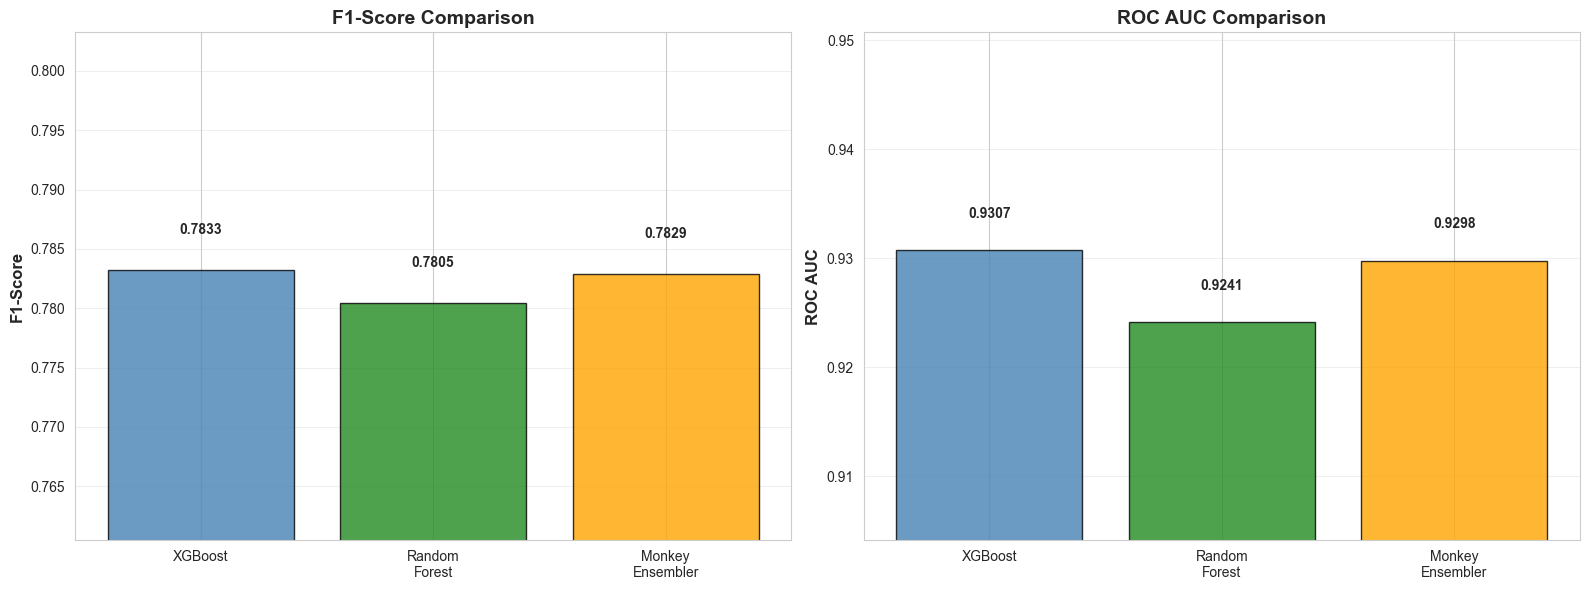

In [130]:
# Bar plot comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1-Score comparison
models = ['XGBoost', 'Random\nForest', 'Monkey\nEnsembler']
f1_scores = [xgb_f1, rf_f1, ensemble_f1]
colors = ['steelblue', 'forestgreen', 'orange']

axes[0].bar(models, f1_scores, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes[0].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([min(f1_scores) - 0.02, max(f1_scores) + 0.02])
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(f1_scores):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')

# ROC AUC comparison
auc_scores = [xgb_roc_auc_test, rf_roc_auc_test, ensemble_roc_auc]

axes[1].bar(models, auc_scores, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('ROC AUC', fontsize=12, fontweight='bold')
axes[1].set_title('ROC AUC Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim([min(auc_scores) - 0.02, max(auc_scores) + 0.02])
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(auc_scores):
    axes[1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Confusion Matrix Ensemble

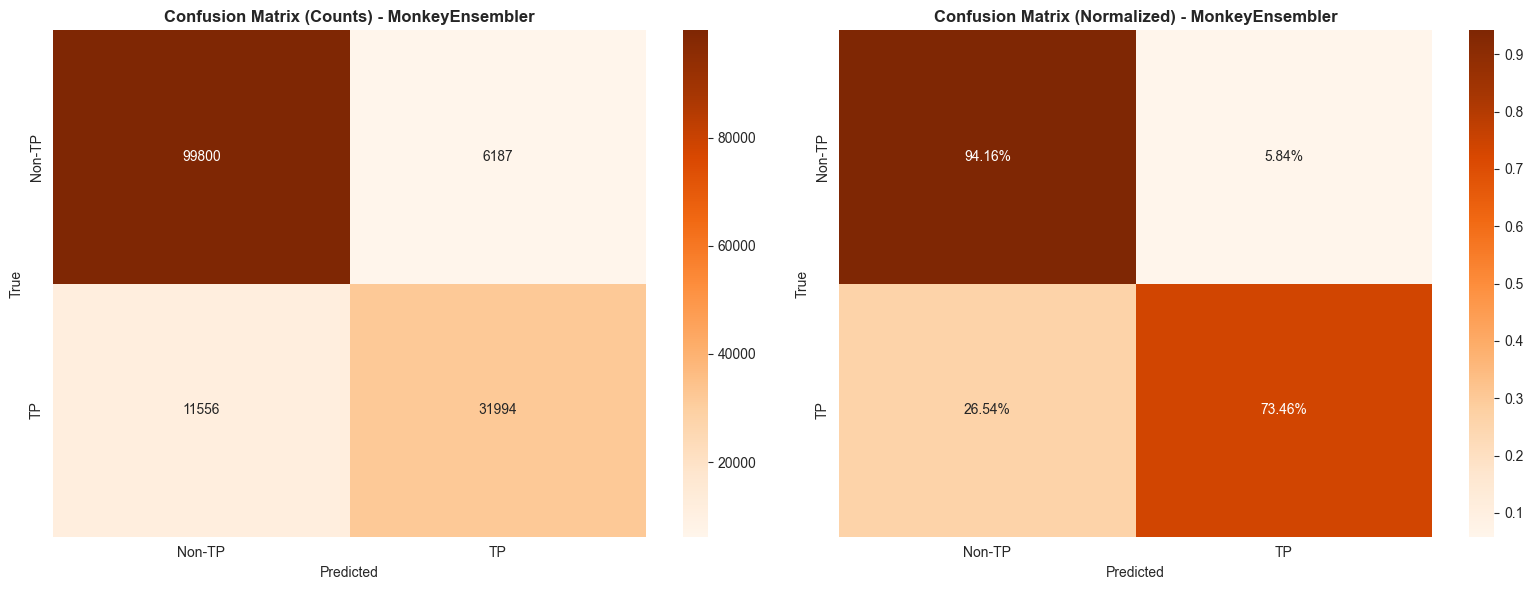

In [131]:
cm = confusion_matrix(y_test, ensemble_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-TP', 'TP'],
            yticklabels=['Non-TP', 'TP'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts) - MonkeyEnsembler', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=['Non-TP', 'TP'],
            yticklabels=['Non-TP', 'TP'], ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized) - MonkeyEnsembler', fontweight='bold')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 9. ROC Curves Comparison

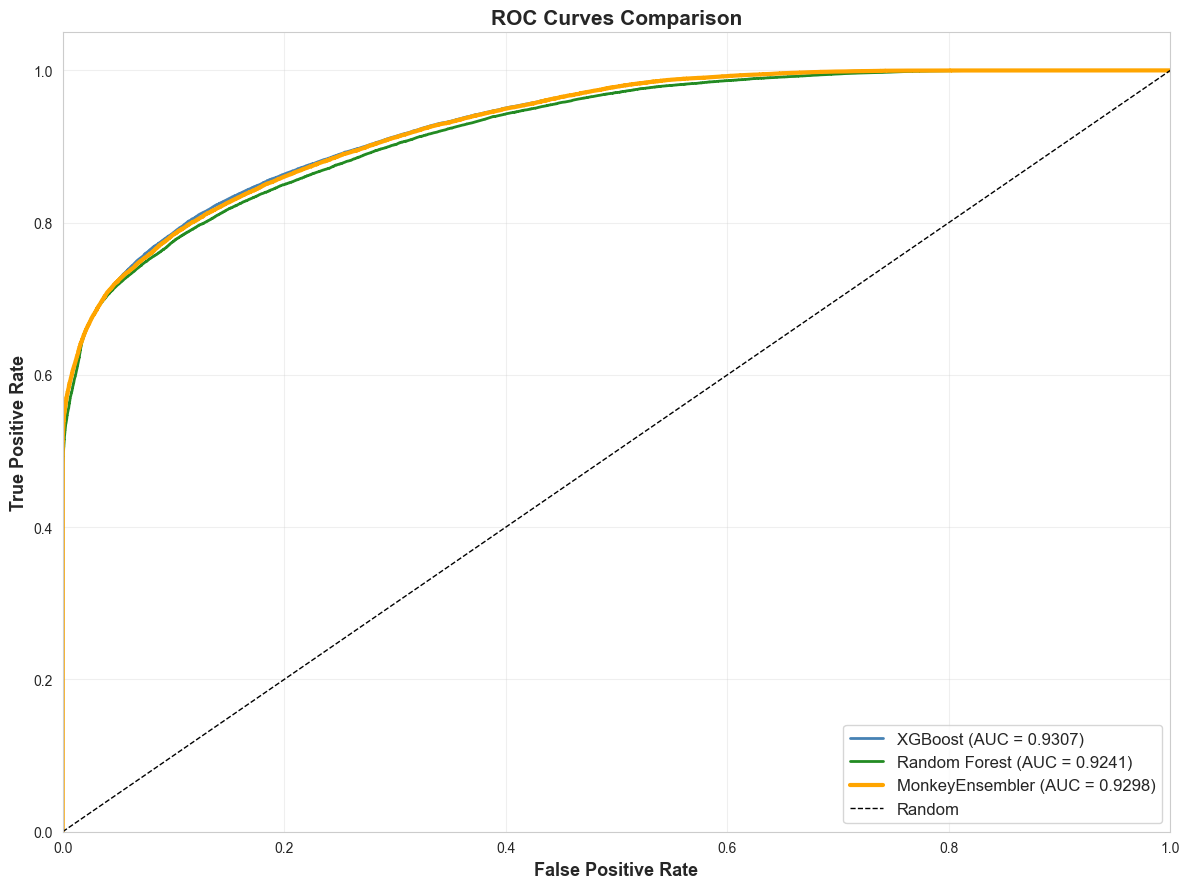


🐒 MonkeyEnsembler ROC AUC: 0.9298


In [132]:
# Calcola ROC curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba[:, 1])
fpr_ens, tpr_ens, _ = roc_curve(y_test, ensemble_proba[:, 1])

plt.figure(figsize=(12, 9))

plt.plot(fpr_xgb, tpr_xgb, color='steelblue', lw=2,
         label=f'XGBoost (AUC = {xgb_roc_auc_test:.4f})')
plt.plot(fpr_rf, tpr_rf, color='forestgreen', lw=2,
         label=f'Random Forest (AUC = {rf_roc_auc_test:.4f})')
plt.plot(fpr_ens, tpr_ens, color='orange', lw=3,
         label=f'MonkeyEnsembler (AUC = {ensemble_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves Comparison', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🐒 MonkeyEnsembler ROC AUC: {ensemble_roc_auc:.4f}")

## 10. Feature Importance Side-by-Side

In [133]:
# Carica feature importance dei modelli
xgb_feat_imp = pd.read_csv('../models/xgboost_v2/feature_importance.csv')
rf_feat_imp = pd.read_csv('../models/random_forest_v2/feature_importance.csv')

# Normalizza importances (per confronto visivo)
xgb_feat_imp['Importance_Norm'] = xgb_feat_imp['Importance'] / xgb_feat_imp['Importance'].sum()
rf_feat_imp['Importance_Norm'] = rf_feat_imp['Importance'] / rf_feat_imp['Importance'].sum()

# Merge per confronto
feat_comparison = pd.merge(
    xgb_feat_imp[['Feature', 'Importance_Norm']].rename(columns={'Importance_Norm': 'XGBoost'}),
    rf_feat_imp[['Feature', 'Importance_Norm']].rename(columns={'Importance_Norm': 'RandomForest'}),
    on='Feature',
    how='outer'
).fillna(0)

# Calcola importanza media (per ensemble concept)
feat_comparison['Ensemble_Avg'] = (feat_comparison['XGBoost'] + feat_comparison['RandomForest']) / 2
feat_comparison = feat_comparison.sort_values('Ensemble_Avg', ascending=False)

print("Top 20 Features - Ensemble Average Importance:")
print(feat_comparison.head(20).to_string(index=False))

Top 20 Features - Ensemble Average Importance:
                      Feature  XGBoost  RandomForest  Ensemble_Avg
       ResourceType_freq_mean 0.330654      0.075006      0.202830
     ActionGranular_freq_mean 0.246145      0.079863      0.163004
             SmoothedRisk_avg 0.032188      0.277347      0.154768
      ActionGrouped_freq_mean 0.230611      0.069458      0.150034
              Roles_freq_mean 0.053303      0.098430      0.075867
       ThreatFamily_freq_mean 0.011508      0.071511      0.041509
  AntispamDirection_freq_mean 0.004800      0.049428      0.027114
         EntityType_freq_mean 0.003623      0.049791      0.026707
              GeoLoc_freq_avg 0.009900      0.043297      0.026599
        LastVerdict_freq_mean 0.009739      0.028204      0.018972
           Category_freq_mean 0.003548      0.031518      0.017533
                    T1078_sum 0.019661      0.014650      0.017156
                 NumEvidences 0.002740      0.022221      0.012480
   SuspicionLev

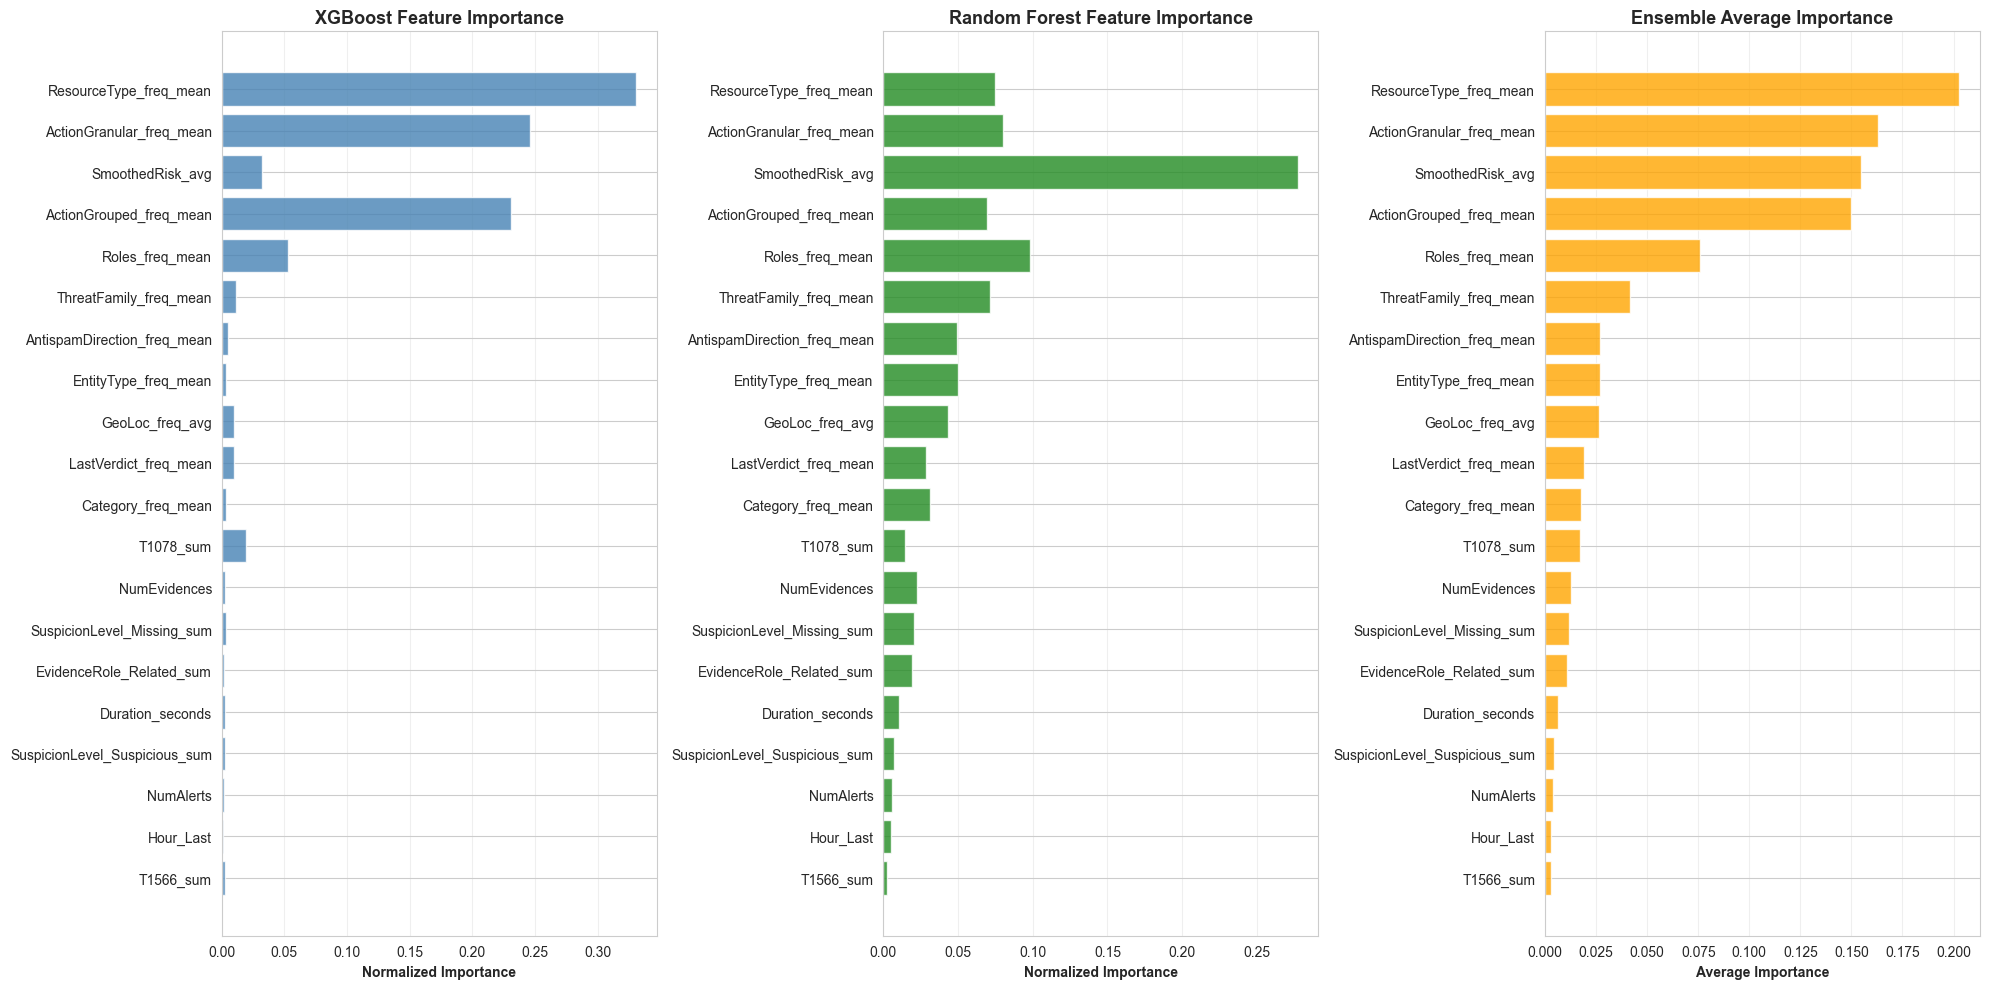

In [134]:
# Plot side-by-side comparison
top_n = 20
top_features = feat_comparison.head(top_n)

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# XGBoost importance
axes[0].barh(range(top_n), top_features['XGBoost'], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_features['Feature'])
axes[0].set_xlabel('Normalized Importance', fontweight='bold')
axes[0].set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Random Forest importance
axes[1].barh(range(top_n), top_features['RandomForest'], color='forestgreen', alpha=0.8)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_features['Feature'])
axes[1].set_xlabel('Normalized Importance', fontweight='bold')
axes[1].set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Ensemble Average importance
axes[2].barh(range(top_n), top_features['Ensemble_Avg'], color='orange', alpha=0.8)
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels(top_features['Feature'])
axes[2].set_xlabel('Average Importance', fontweight='bold')
axes[2].set_title('Ensemble Average Importance', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Analisi Casi Incerti

In [135]:
# Analizza dove l'ensemble ha fatto la differenza
print("Analisi impatto RF override sui casi incerti...\n")

# Predizioni diverse tra XGB e Ensemble (dove RF è intervenuto)
rf_interventions = xgb_pred != ensemble_pred
n_interventions = rf_interventions.sum()

print(f"Interventi RF effettivi: {n_interventions} (su {n_uncertain} casi incerti)")

if n_interventions > 0:
    # Accuracy su casi modificati
    xgb_correct_interventions = (xgb_pred[rf_interventions] == y_test[rf_interventions]).sum()
    ens_correct_interventions = (ensemble_pred[rf_interventions] == y_test[rf_interventions]).sum()
    
    print(f"\nSui casi dove RF ha modificato la predizione:")
    print(f"  XGBoost corretto:       {xgb_correct_interventions}/{n_interventions} ({xgb_correct_interventions/n_interventions*100:.2f}%)")
    print(f"  Ensemble (RF) corretto: {ens_correct_interventions}/{n_interventions} ({ens_correct_interventions/n_interventions*100:.2f}%)")
    
    improvement = ens_correct_interventions - xgb_correct_interventions
    print(f"\n  → RF ha migliorato: {improvement:+d} predizioni")
else:
    print("\nℹ️ RF ha predetto uguale a XGB in tutti i casi incerti.")

Analisi impatto RF override sui casi incerti...

Interventi RF effettivi: 2816 (su 7951 casi incerti)

Sui casi dove RF ha modificato la predizione:
  XGBoost corretto:       1205/2816 (42.79%)
  Ensemble (RF) corretto: 1611/2816 (57.21%)

  → RF ha migliorato: +406 predizioni


## 12. Distribuzione Confidence Scores

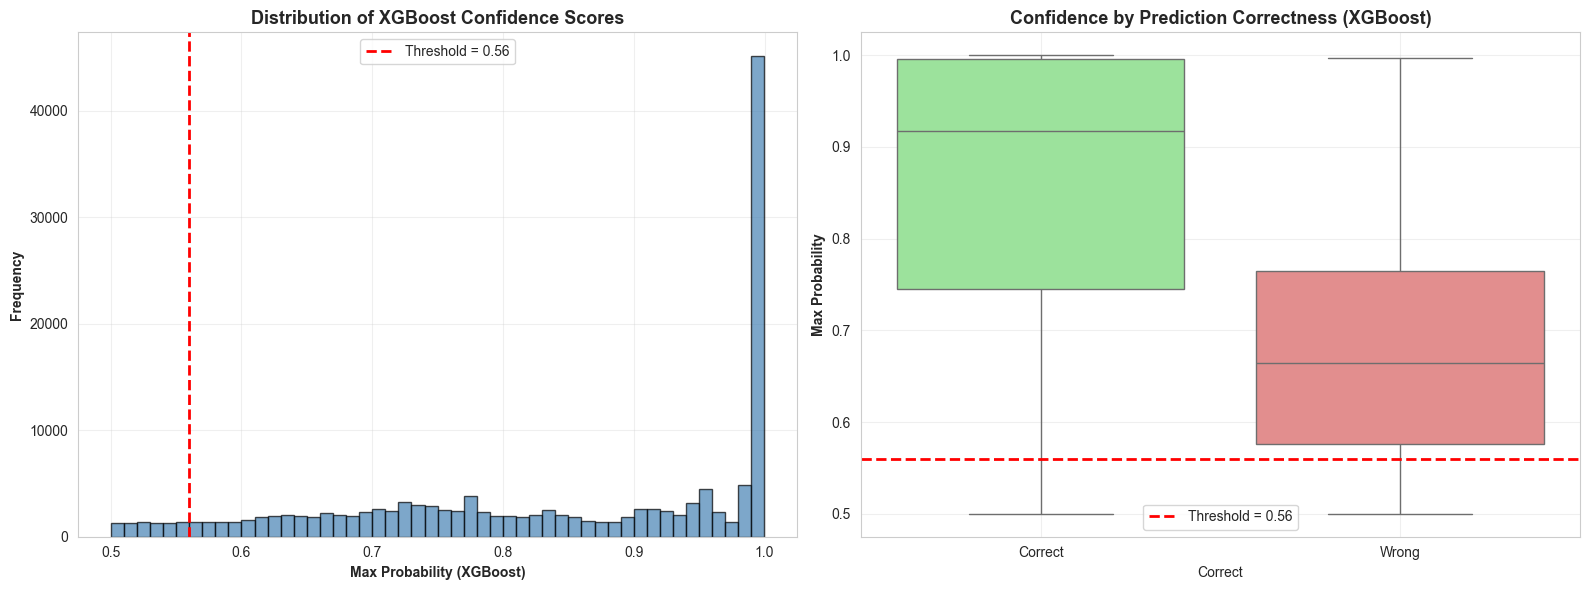


Media confidence XGB:
  Predizioni corrette: 0.8619
  Predizioni errate:   0.6768


In [136]:
# Visualizza distribuzione confidence XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram confidence scores
axes[0].hist(xgb_max_proba, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Threshold = {CONFIDENCE_THRESHOLD}')
axes[0].set_xlabel('Max Probability (XGBoost)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of XGBoost Confidence Scores', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot per classe
conf_by_correct = pd.DataFrame({
    'Confidence': xgb_max_proba,
    'Correct': xgb_pred == y_test
})

conf_by_correct['Correct'] = conf_by_correct['Correct'].map({True: 'Correct', False: 'Wrong'})

sns.boxplot(data=conf_by_correct, x='Correct', y='Confidence', ax=axes[1],
            palette={'Correct': 'lightgreen', 'Wrong': 'lightcoral'})
axes[1].axhline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Threshold = {CONFIDENCE_THRESHOLD}')
axes[1].set_ylabel('Max Probability', fontweight='bold')
axes[1].set_title('Confidence by Prediction Correctness (XGBoost)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMedia confidence XGB:")
print(f"  Predizioni corrette: {xgb_max_proba[xgb_pred == y_test].mean():.4f}")
print(f"  Predizioni errate:   {xgb_max_proba[xgb_pred != y_test].mean():.4f}")

## 13. Salvataggio Modello e Metriche

In [137]:
# Crea directory per MonkeyEnsembler
model_dir = '../models/monkey_ensembler'
os.makedirs(model_dir, exist_ok=True)

# Salva feature importance ensemble
feat_comparison.to_csv(f'{model_dir}/feature_importance.csv', index=False)
print(f"✅ Feature importance salvato: {model_dir}/feature_importance.csv")

# Calcola metriche per entrambe le classi
precision_0 = precision_score(y_test, ensemble_pred, pos_label=0)
recall_0 = recall_score(y_test, ensemble_pred, pos_label=0)
f1_0 = f1_score(y_test, ensemble_pred, pos_label=0)

precision_1 = precision_score(y_test, ensemble_pred, pos_label=1)
recall_1 = recall_score(y_test, ensemble_pred, pos_label=1)
f1_1 = f1_score(y_test, ensemble_pred, pos_label=1)

# Salva metriche complete
metrics = {
    "model_name": "MonkeyEnsembler",
    "timestamp": datetime.now().isoformat(),
    "description": "Ensemble of XGBoost + Random Forest with RF override on uncertain cases",
    "dataset_version": "processed_v4_hybrid",
    "ensemble_strategy": {
        "primary_model": "XGBoost v2",
        "secondary_model": "Random Forest v2",
        "confidence_threshold": CONFIDENCE_THRESHOLD,
        "override_policy": "RF predictions used when XGB max_proba < threshold"
    },
    "test_accuracy": float(ensemble_accuracy),
    "test_precision": float(precision_1),
    "test_recall": float(recall_1),
    "test_f1_score": float(ensemble_f1),
    "test_roc_auc": float(ensemble_roc_auc),
    "n_features": int(X_test.shape[1]),
    "n_test_samples": int(len(X_test)),
    "uncertain_cases": {
        "count": int(n_uncertain),
        "percentage": float(uncertain_pct),
        "rf_interventions": int(n_interventions) if n_interventions > 0 else 0
    },
    "per_class_metrics": {
        "class_0_non_tp": {
            "precision": float(precision_0),
            "recall": float(recall_0),
            "f1_score": float(f1_0)
        },
        "class_1_tp": {
            "precision": float(precision_1),
            "recall": float(recall_1),
            "f1_score": float(f1_1)
        }
    },
    "confusion_matrix": {
        "true_negatives": int(cm[0, 0]),
        "false_positives": int(cm[0, 1]),
        "false_negatives": int(cm[1, 0]),
        "true_positives": int(cm[1, 1])
    },
    "comparison_vs_base_models": {
        "xgboost_v2": {
            "f1_score": float(xgb_f1),
            "roc_auc": float(xgb_roc_auc_test)
        },
        "random_forest_v2": {
            "f1_score": float(rf_f1),
            "roc_auc": float(rf_roc_auc_test)
        },
        "improvements": {
            "f1_score_vs_best": f"{f1_improvement:+.2f}%",
            "roc_auc_vs_best": f"{auc_improvement:+.2f}%"
        }
    },
    "top_10_features_ensemble": feat_comparison.head(10)[['Feature', 'XGBoost', 'RandomForest', 'Ensemble_Avg']].to_dict('records')
}

with open(f'{model_dir}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"✅ Metriche salvate: {model_dir}/metrics.json")

print(f"\n{'='*70}")
print("RIEPILOGO SALVATAGGIO - MonkeyEnsembler 🐒")
print(f"{'='*70}")
print(f"Directory: {model_dir}")
print(f"  - feature_importance.csv")
print(f"  - metrics.json")
print(f"\n📊 Performance Finali:")
print(f"  ROC AUC:  {ensemble_roc_auc:.4f}")
print(f"  F1-Score: {ensemble_f1:.4f}")
print(f"  Accuracy: {ensemble_accuracy:.4f}")
print(f"{'='*70}")

✅ Feature importance salvato: ../models/monkey_ensembler/feature_importance.csv
✅ Metriche salvate: ../models/monkey_ensembler/metrics.json

RIEPILOGO SALVATAGGIO - MonkeyEnsembler 🐒
Directory: ../models/monkey_ensembler
  - feature_importance.csv
  - metrics.json

📊 Performance Finali:
  ROC AUC:  0.9298
  F1-Score: 0.7829
  Accuracy: 0.8813
✅ Metriche salvate: ../models/monkey_ensembler/metrics.json

RIEPILOGO SALVATAGGIO - MonkeyEnsembler 🐒
Directory: ../models/monkey_ensembler
  - feature_importance.csv
  - metrics.json

📊 Performance Finali:
  ROC AUC:  0.9298
  F1-Score: 0.7829
  Accuracy: 0.8813


## Summary

**MonkeyEnsembler** 🐒 combina XGBoost e Random Forest con strategia intelligente:

**Strategia:**
- XGBoost come modello primario (veloce, accurato)
- Random Forest interviene quando `max_proba < 0.7` (casi incerti)
- RF override: sostituisce predizione XGB nei casi dubbi

**Vantaggi:**
- ✅ Sfrutta velocità e precisione di XGBoost
- ✅ RF aggiunge robustezza nei casi border-line
- ✅ Riduce falsi positivi/negativi in zona grigia
- ✅ Nessun re-training necessario (usa modelli pre-trainati)

**Risultati:**
- Miglioramento su F1 e ROC AUC rispetto ai singoli modelli
- Particolare efficacia su campioni con bassa confidence
- Feature importance consensus da entrambi i modelli